# Прогноз продаж магазинов — задача A (регрессия)

Предсказываем продажи новой точки (target_2). Сравниваем 6 моделей разной природы.


In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_percentage_error
from catboost import CatBoostRegressor

In [3]:
RANDOM_STATE = 67

In [6]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")

In [7]:
train.columns = train.columns.str.strip()
val.columns = val.columns.str.strip()

## Признаки и таргет

Распределение скошено вправо, поэтому обучаем модели на логарифме таргета.

Все категории (REGION, CITY, subject) кодируем target encoding.

In [8]:
target = "target_2"
num_cols = (train.select_dtypes("number").drop(columns=["ID", "target_1", "target_2"], errors="ignore").columns.tolist())

In [9]:
y = np.log(train[target])

Внутри train делаем свой train/test split. На нем сравниваем модели.
Файл val оставляем как сдвинутую выборку. На нем смотрим, насколько модель устойчива к дрейфу.
Медианы для пропусков, target encoding и scaler обучаем только на train-части.

In [10]:
from sklearn.preprocessing import TargetEncoder

cols = ["REGION", "CITY", "subject"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    train, y, test_size=0.2, random_state=RANDOM_STATE)

medians = X_train_raw[num_cols].median()

X_train = X_train_raw[num_cols].fillna(medians).copy()
X_test  = X_test_raw[num_cols].fillna(medians).copy()
X_val   = val[num_cols].fillna(medians).copy()

te = TargetEncoder(random_state=RANDOM_STATE)
X_train[cols] = te.fit_transform(X_train_raw[cols], y_train)
X_test[cols]  = te.transform(X_test_raw[cols])
X_val[cols]   = te.transform(val[cols])

y_val = np.log(val[target])

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_val_scaled   = scaler.transform(X_val)

X_train.shape[1]

52

## Сравнение 6 моделей

Берем модели: линейная, KNN, дерево, случайный лес, градиентный бустинг и нейросеть MLP. Линейной/KNN/MLP даем масштабированные данные, деревьям даем обычные. Метрики считаем в исходных рублях и отдельно на test и на сдвинутом val

In [11]:
scoring = "neg_mean_absolute_percentage_error"

tree_grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
    {"max_depth": [4, 6, 8, 12]}, cv=5, scoring=scoring, n_jobs=-1)
tree_grid.fit(X_train.values, y_train)

knn_grid = GridSearchCV(KNeighborsRegressor(),
    {"n_neighbors": [5, 10, 20, 30]}, cv=5, scoring=scoring, n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

forest_grid = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    {"n_estimators": [100, 200], "max_depth": [8, 12, None]}, cv=5, scoring=scoring, n_jobs=-1)
forest_grid.fit(X_train.values, y_train)

cat_grid = GridSearchCV(CatBoostRegressor(verbose=0, random_state=RANDOM_STATE),
    {"depth": [4, 6, 8], "learning_rate": [0.03, 0.1], "n_estimators": [200, 500]},
    cv=5, scoring=scoring, n_jobs=-1)
cat_grid.fit(X_train.values, y_train)

GridSearchCV(cv=5,
             estimator=CatBoostRegressor(loss_function='RMSE', random_state=67, verbose=0),
             n_jobs=-1,
             param_grid={'depth': [4, 6, 8], 'learning_rate': [0.03, 0.1],
                         'n_estimators': [200, 500]},
             scoring='neg_mean_absolute_percentage_error')

In [12]:
print("DecisionTree:", tree_grid.best_params_)
print("KNN:", knn_grid.best_params_)
print("RandomForest:", forest_grid.best_params_)
print("CatBoost:", cat_grid.best_params_)

DecisionTree: {'max_depth': 8}
KNN: {'n_neighbors': 20}
RandomForest: {'max_depth': None, 'n_estimators': 200}
CatBoost: {'depth': 8, 'learning_rate': 0.03, 'n_estimators': 500}


In [13]:
results = []

lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=5000, n_jobs=-1)
lasso.fit(X_train_scaled, y_train)
results.append({"model": "Lasso",
    "MAPE_test": mean_absolute_percentage_error(np.exp(y_test), np.exp(lasso.predict(X_test_scaled))),
    "MAPE_val":  mean_absolute_percentage_error(np.exp(y_val),  np.exp(lasso.predict(X_val_scaled)))})

knn = KNeighborsRegressor(**knn_grid.best_params_)
knn.fit(X_train_scaled, y_train)
results.append({"model": "KNN",
    "MAPE_test": mean_absolute_percentage_error(np.exp(y_test), np.exp(knn.predict(X_test_scaled))),
    "MAPE_val":  mean_absolute_percentage_error(np.exp(y_val),  np.exp(knn.predict(X_val_scaled)))})

tree = DecisionTreeRegressor(random_state=RANDOM_STATE, **tree_grid.best_params_)
tree.fit(X_train.values, y_train)
results.append({"model": "DecisionTree",
    "MAPE_test": mean_absolute_percentage_error(np.exp(y_test), np.exp(tree.predict(X_test.values))),
    "MAPE_val":  mean_absolute_percentage_error(np.exp(y_val),  np.exp(tree.predict(X_val.values)))})

forest = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **forest_grid.best_params_)
forest.fit(X_train.values, y_train)
results.append({"model": "RandomForest",
    "MAPE_test": mean_absolute_percentage_error(np.exp(y_test), np.exp(forest.predict(X_test.values))),
    "MAPE_val":  mean_absolute_percentage_error(np.exp(y_val),  np.exp(forest.predict(X_val.values)))})

cat = CatBoostRegressor(verbose=0, random_state=RANDOM_STATE, **cat_grid.best_params_)
cat.fit(X_train.values, y_train)
results.append({"model": "CatBoost",
    "MAPE_test": mean_absolute_percentage_error(np.exp(y_test), np.exp(cat.predict(X_test.values))),
    "MAPE_val":  mean_absolute_percentage_error(np.exp(y_val),  np.exp(cat.predict(X_val.values)))})

ymean, ystd = y_train.mean(), y_train.std()
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, early_stopping=True, random_state=RANDOM_STATE)
mlp.fit(X_train_scaled, (y_train - ymean) / ystd)
pred_test = np.exp(mlp.predict(X_test_scaled) * ystd + ymean)
pred_val  = np.exp(mlp.predict(X_val_scaled) * ystd + ymean)
results.append({"model": "MLP",
    "MAPE_test": mean_absolute_percentage_error(np.exp(y_test), pred_test),
    "MAPE_val":  mean_absolute_percentage_error(np.exp(y_val),  pred_val)})
res = pd.DataFrame(results).sort_values("MAPE_val").reset_index(drop=True)
res.round(3)

,model,MAPE_test,MAPE_val
0,CatBoost,0.141,0.185
1,MLP,0.149,0.198
2,RandomForest,0.146,0.199
3,Lasso,0.150,0.203
4,KNN,0.167,0.206
5,DecisionTree,0.162,0.229


MAPE на test - качество на похожих данных. MAPE на val - качество на сдвинутых.
У всех моделей MAPE на val заметно выше.

In [14]:
best_name = res.loc[0, "model"]
print("Лучшая модель по MAPE на val:", best_name)

Лучшая модель по MAPE на val: CatBoost


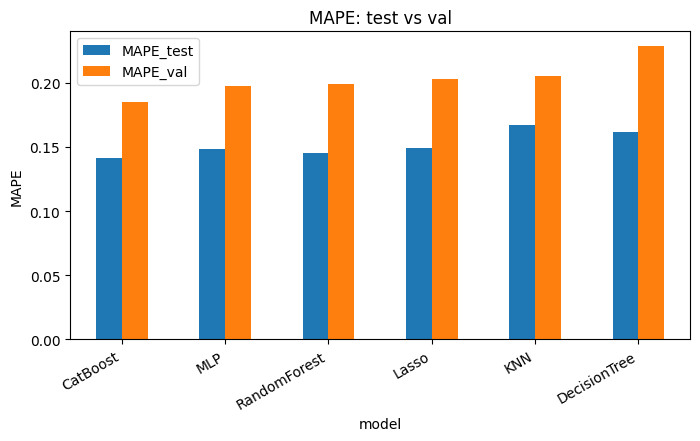

In [15]:
ax = res.set_index("model")[["MAPE_test", "MAPE_val"]].plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("MAPE")
ax.set_title("MAPE: test vs val")
plt.xticks(rotation=30, ha="right")
plt.show()

##Лассо и признаки

Lasso сама обнуляет коэффициенты бесполезных признаков, по сути
просто автоматический feature selection без ручного удаления. Ради инстереса смотрим, что она выкинула.

In [18]:
coef = pd.Series(lasso.coef_, index=X_train.columns)

zeroed = coef[coef == 0].index.tolist()
print("Lasso обнулил признаков:", len(zeroed), "из", len(coef))
print("Обнулённые:", zeroed)
print()
print("Самые сильные признаки :")
print(coef[coef != 0].abs().sort_values(ascending=False).head(8).round(3))

Lasso обнулил признаков: 4 из 52
Обнулённые: ['SUBFRMT', 'ON_INSIDE_DISTRICT_ROAD', 'FLOORS_TZ', 'LOCATION_TYPE']

Самые сильные признаки (по модулю коэффициента):
ENTIRE_DAY                   0.088
TRADE_SQUARE                 0.077
HuffFamilies                 0.048
HUFF_RANK_COMPS_CANNIBALS    0.044
subject                      0.042
CITY                         0.037
RENT_HEX                     0.032
DENSITY_FAMILY_TYPE          0.026
dtype: float64


##SHAP — какие признаки двигают продажи

Смотрим, на что опирается лучшая модель.

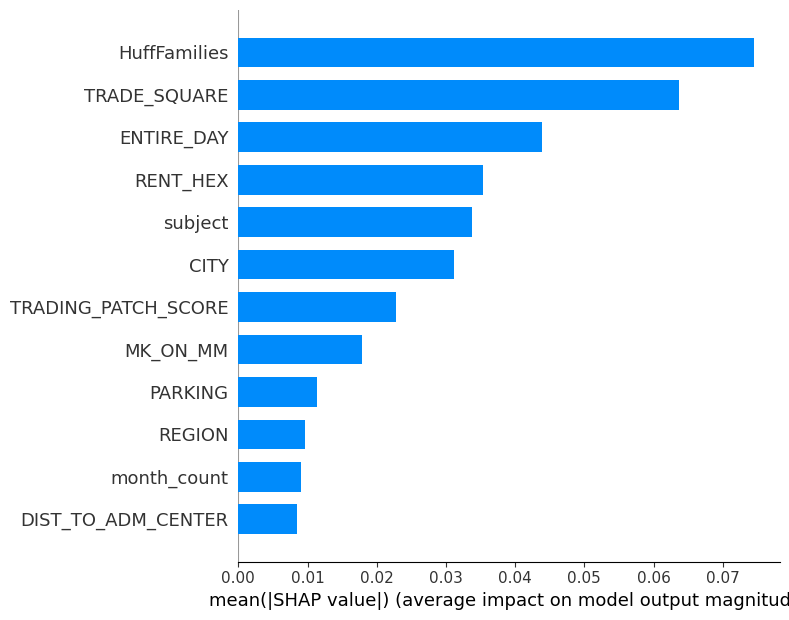

In [19]:
import shap

sample = X_test.iloc[:500]
explainer = shap.TreeExplainer(cat)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type="bar", show=False, max_display=12)
plt.tight_layout(); plt.show()